In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_recall_curve

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
import shap
import warnings
from sklearn.exceptions import ConvergenceWarning
import shap

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
# same code used for each dataset, just change the path
df = pd.read_csv("dmean_df.csv")
print(df.shape)

# df = pd.read_csv("dmax_df.csv")
# print(df.columns)
# print(df.shape)

In [ ]:
# ensuring 80/20 split based on PatientID
y = df["ExtractionFlag"]
X = df.drop(columns=["ExtractionFlag"])

X_dummies = pd.get_dummies(
    X,
    columns=[c for c in X.columns if c not in ["TotalDose", "PatientID"]],
    drop_first=False,
    dtype=float
)

unique_patients = df['PatientID'].unique()

train_patients, test_patients = train_test_split(
    unique_patients, 
    test_size=0.2, 
    random_state=42
)

train_mask = df['PatientID'].isin(train_patients)
test_mask = df['PatientID'].isin(test_patients)

X_train = X_dummies[train_mask]
X_test = X_dummies[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

X_train = X_train.drop(columns=["PatientID"])
X_test = X_test.drop(columns=["PatientID"])

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# LR + L1 

In [ ]:
pipe = Pipeline([
    ("scaler", MaxAbsScaler()), 
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=20000,
        random_state=42
    ))
])

param_grid = {
    "clf__C":           [0.01, 0.1, 1, 10],
    "clf__class_weight": [
        {0: 1, 1: 4},
        {0: 1, 1: 2},
        "balanced"
    ],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best class_weight:", grid.best_estimator_.named_steps["clf"].class_weight)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not conver

Best params: {'clf__C': 10, 'clf__class_weight': 'balanced'}
Best class_weight: balanced


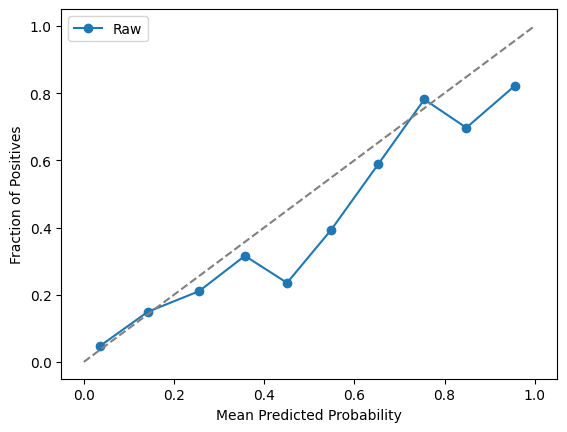

Uncalibrated Brier: 0.16763795826613972
Uncalibrated ROC AUC: 0.8392971569255674


In [ ]:
proba_raw = grid.predict_proba(X_test)[:, 1]

# Compute calibration‐curve data
prob_true_raw, prob_pred_raw = calibration_curve(y_test, proba_raw, n_bins=10)

plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

print("Uncalibrated Brier:", brier_score_loss(y_test, proba_raw))
print("Uncalibrated ROC AUC:", roc_auc_score(y_test, proba_raw))

In [ ]:
# Evaluate on test set
y_pred  = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:,1]


# Brier score 
brier = brier_score_loss(y_test, proba_raw)
print(f"Brier score: {brier:.4f}")


for thr in [0.5]:
    y_thr = (proba_raw >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_thr)
    print(f"\nThreshold={thr} Confusion Matrix:\n{cm_thr}")
    print(classification_report(y_test, y_thr))

# Weighted cross-entropy 
classes = np.unique(y_test)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_test)
class_weight_dict = dict(zip(classes, cw))

sample_weights = np.array([class_weight_dict[y] for y in y_test])

wlog = log_loss(y_test, proba_raw, sample_weight=sample_weights)
print(f"Weighted log-loss: {wlog:.4f}")

Brier score: 0.1676

Threshold=0.5 Confusion Matrix:
[[141  58]
 [ 24 125]]
              precision    recall  f1-score   support

           0       0.85      0.71      0.77       199
           1       0.68      0.84      0.75       149

    accuracy                           0.76       348
   macro avg       0.77      0.77      0.76       348
weighted avg       0.78      0.76      0.77       348

Weighted log-loss: 0.5194


/var/folders/8m/xsxvn0ns46dg_dpnlhpkxk6r0000gn/T/ipykernel_44310/3264799448.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby('bin')['true'].value_counts().unstack().fillna(0)


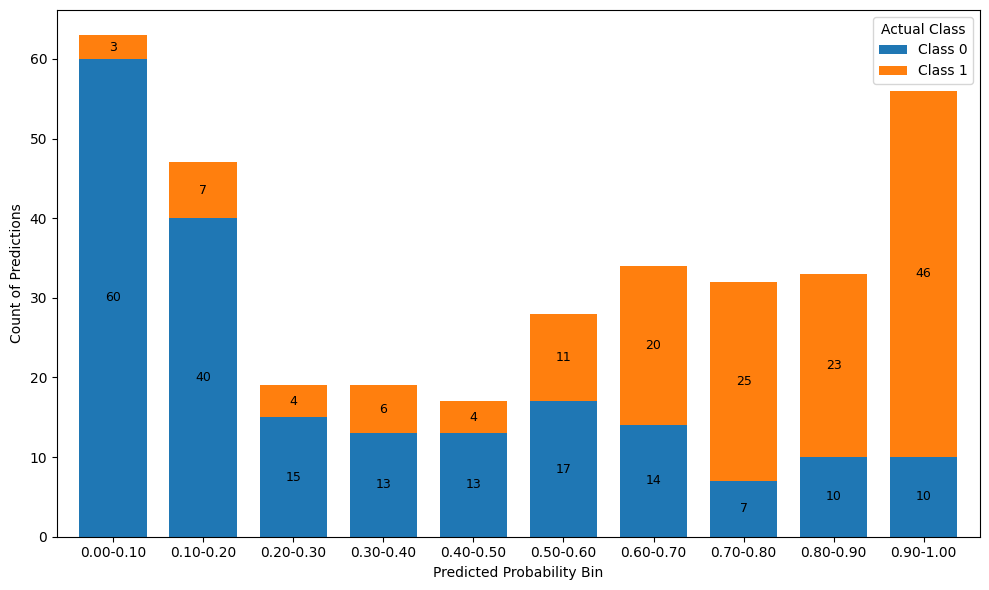

In [ ]:
bins = np.arange(0, 1.1, 0.1)
bin_labels = [f"{b:.2f}-{b+0.1:.2f}" for b in bins[:-1]]

df = pd.DataFrame({
    'prob': y_proba,
    'true': y_test,
    'bin': pd.cut(y_proba, bins=bins, labels=bin_labels, include_lowest=True)
})

counts = df.groupby('bin')['true'].value_counts().unstack().fillna(0)
counts.columns = ['Class 0', 'Class 1']

fig, ax = plt.subplots(figsize=(10, 6))    
counts.plot(kind='bar', 
            stacked=True, 
            ax=ax, 
            width=0.75)                   
plt.xlabel('Predicted Probability Bin')
plt.ylabel('Count of Predictions')
plt.xticks(rotation=0)
plt.legend(title='Actual Class', loc='upper right')
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.annotate(f'{int(height)}', 
                    (x + p.get_width()/2, y + height/2), 
                    ha='center', va='center', 
                    color='black', fontsize=9)

plt.show()


# SHAP

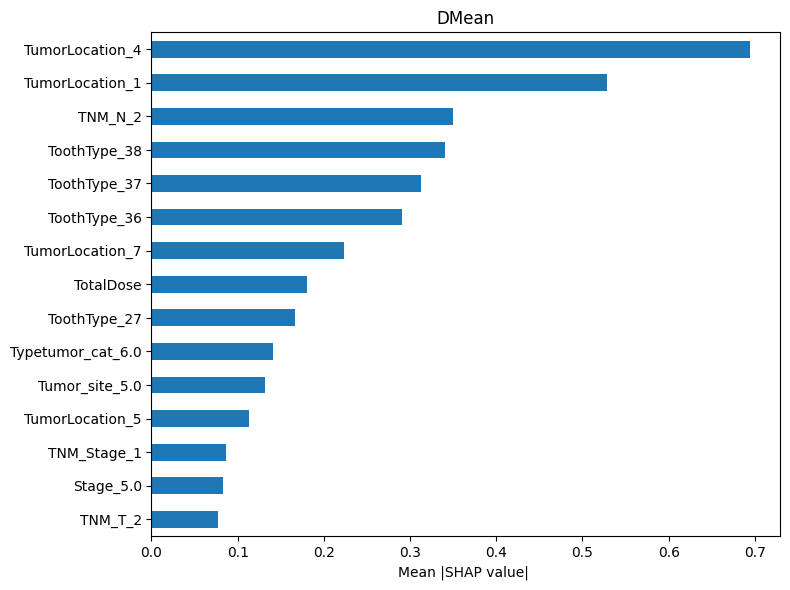

In [ ]:
# Extract the best LR model
best_model    = grid.best_estimator_
log_reg       = best_model.named_steps['clf']
scaler        = best_model.named_steps['scaler']

# Scale the data 
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)  

# SHAP explainer using training data as background
explainer      = shap.LinearExplainer(
    log_reg,
    X_train_scaled,
    feature_names=X_train.columns
)

# Calculate SHAP values on the test set
shap_values_test = explainer.shap_values(X_test_scaled)

# Aggregate and rank feature importances
shap_df    = pd.DataFrame(shap_values_test, columns=X_train.columns)
mean_abs   = shap_df.abs().mean().sort_values(ascending=True)
top15      = mean_abs.nlargest(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind="barh")   
plt.title("DMean")
plt.xlabel("Mean |SHAP value| ")
plt.tight_layout()
plt.show()